# Week 2 Assignment
### Tesla Deliveries - End-to-End ML Pipeline



Build a complete ML pipeline covering EDA, feature engineering, regression modelling, hyperparameter tuning, and time series forecasting.


## Imports and Setup


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline        import Pipeline

# Time Series
from statsmodels.tsa.stattools   import adfuller
from statsmodels.tsa.seasonal    import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## Data Loading and Overview


In [48]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print('Dataset loaded successfully!')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Dataset loaded successfully!
Rows    : 2,640
Columns : 12


In [3]:
# Preview first 5 rows
print('First 5 rows:')
df.head()

First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
# Column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
# Statistical summary
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [6]:
# Unique values in categorical columns
print('Regions     :', df['Region'].unique().tolist())
print('Car Models  :', df['Model'].unique().tolist())
print('Source Types:', df['Source_Type'].unique().tolist())
print('Year range  :', df['Year'].min(), 'to', df['Year'].max())

Regions     : ['Europe', 'Asia', 'North America', 'Middle East']
Car Models  : ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Source Types: ['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']
Year range  : 2015 to 2025


## Exploratory Data Analysis (EDA)
EDA helps us understand patterns, distributions, and relationships in the data before building any model.



In [7]:
# Check for missing values
print('Missing values per column:')
missing = df.isnull().sum()
print(missing)
print(f'Total missing: {missing.sum()}')
if missing.sum() == 0:
    print('No missing values - dataset is complete!')

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Total missing: 0
No missing values - dataset is complete!


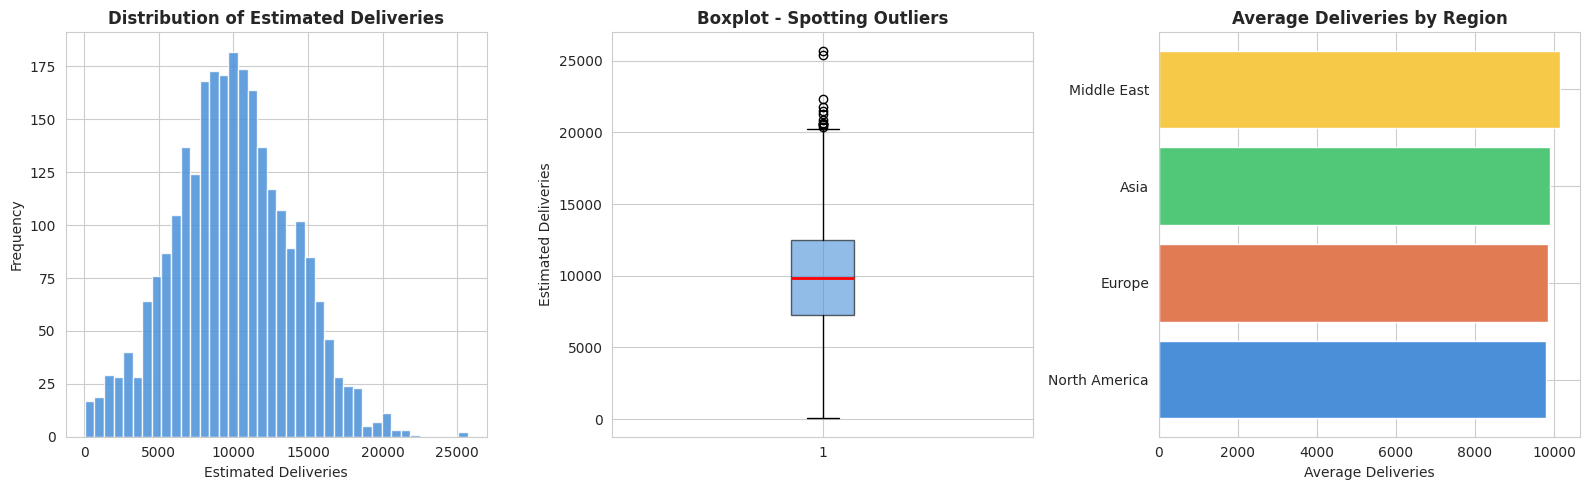

Mean   : 9,922
Median : 9,857
Std    : 3,936
Min    : 48
Max    : 25,704


In [8]:
# Distribution of target variable
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='#4a90d9', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Estimated Deliveries', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estimated Deliveries')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Estimated_Deliveries'], patch_artist=True,
                boxprops=dict(facecolor='#4a90d9', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot - Spotting Outliers', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Estimated Deliveries')

region_means = df.groupby('Region')['Estimated_Deliveries'].mean().sort_values()
axes[2].barh(region_means.index, region_means.values,
             color=['#4a90d9','#e07b54','#50c878','#f7c948'])
axes[2].set_title('Average Deliveries by Region', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Average Deliveries')

plt.tight_layout()
plt.show()

print(f'Mean   : {df["Estimated_Deliveries"].mean():,.0f}')
print(f'Median : {df["Estimated_Deliveries"].median():,.0f}')
print(f'Std    : {df["Estimated_Deliveries"].std():,.0f}')
print(f'Min    : {df["Estimated_Deliveries"].min():,.0f}')
print(f'Max    : {df["Estimated_Deliveries"].max():,.0f}')

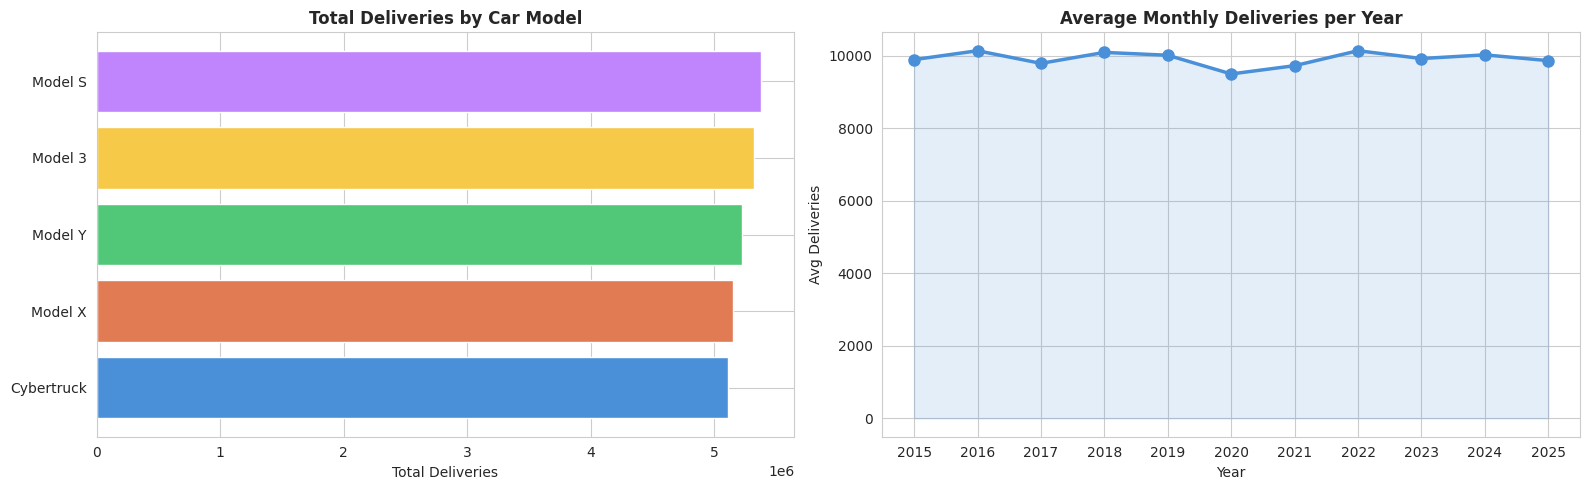

In [9]:
# Deliveries by model and yearly trend
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

model_totals = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
colors_bar = ['#4a90d9','#e07b54','#50c878','#f7c948','#c084fc']
axes[0].barh(model_totals.index, model_totals.values, color=colors_bar)
axes[0].set_title('Total Deliveries by Car Model', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Deliveries')

yearly = df.groupby('Year')['Estimated_Deliveries'].mean()
axes[1].plot(yearly.index, yearly.values, marker='o', linewidth=2.5,
             markersize=8, color='#4a90d9')
axes[1].fill_between(yearly.index, yearly.values, alpha=0.15, color='#4a90d9')
axes[1].set_title('Average Monthly Deliveries per Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Deliveries')
axes[1].set_xticks(yearly.index)

plt.tight_layout()
plt.show()

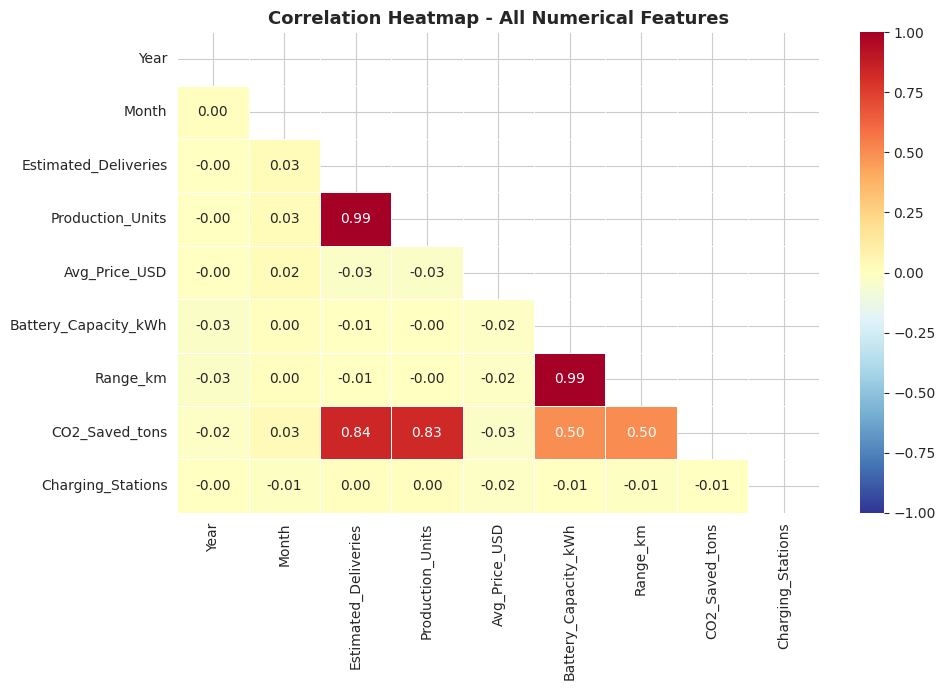

Top correlations with Estimated_Deliveries:
  Production_Units           0.994
  CO2_Saved_tons             0.837
  Month                      0.031
  Charging_Stations          0.001
  Year                      -0.003
  Range_km                  -0.007
  Battery_Capacity_kWh      -0.008
  Avg_Price_USD             -0.028


In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Heatmap - All Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with Estimated_Deliveries:')
top_corr = corr['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values(ascending=False)
for col, val in top_corr.items():
    print(f'  {col:<25} {val:>6.3f}')

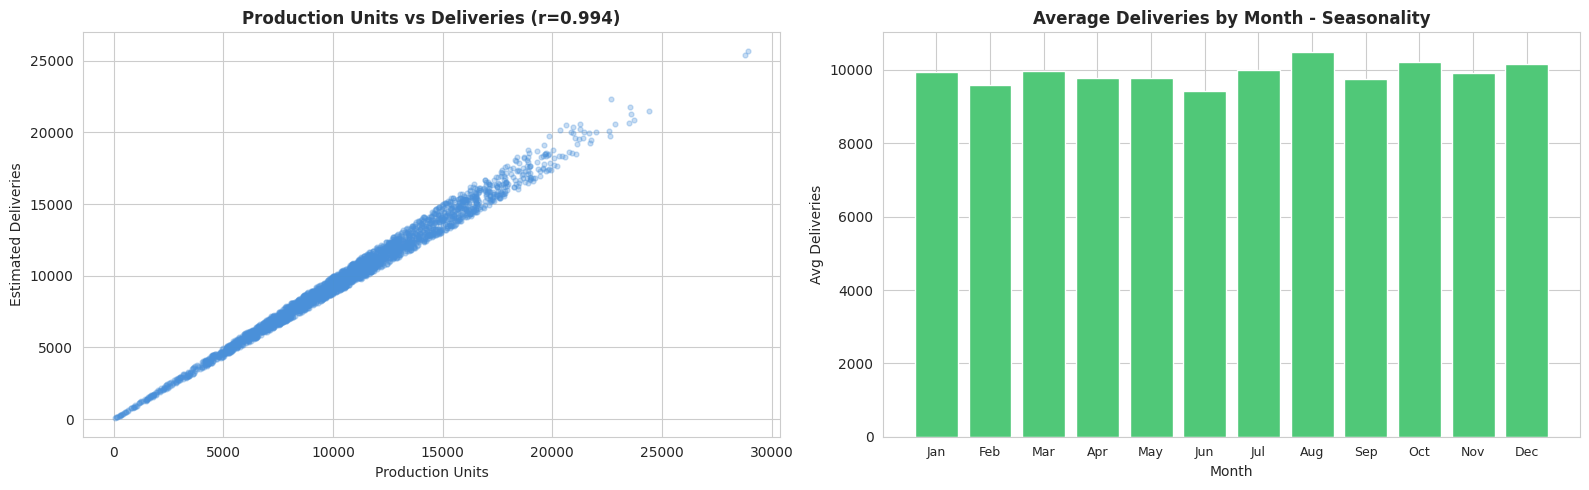

KEY INSIGHT: Production_Units has r=0.994 correlation with deliveries!
This means production capacity is the strongest predictor of delivery volume.


In [11]:
# Production vs Deliveries and monthly seasonality
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df['Production_Units'], df['Estimated_Deliveries'],
                alpha=0.3, s=12, color='#4a90d9')
axes[0].set_title('Production Units vs Deliveries (r=0.994)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Production Units')
axes[0].set_ylabel('Estimated Deliveries')

monthly = df.groupby('Month')['Estimated_Deliveries'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color='#50c878', edgecolor='white')
axes[1].set_title('Average Deliveries by Month - Seasonality', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Deliveries')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, fontsize=9)

plt.tight_layout()
plt.show()

print('KEY INSIGHT: Production_Units has r=0.994 correlation with deliveries!')
print('This means production capacity is the strongest predictor of delivery volume.')

##  Data Cleaning
Clean data leads to better models. We handle:
1. Missing values check
2. Outlier removal using the IQR method
3. Verify the cleaned dataset



In [12]:
df_clean = df.copy()

# Missing values
print('Missing values check:')
print(df_clean.isnull().sum())
print('No missing values found - dataset is complete!')

Missing values check:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
No missing values found - dataset is complete!


In [13]:
# Outlier removal using IQR on target variable
Q1  = df_clean['Estimated_Deliveries'].quantile(0.25)
Q3  = df_clean['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Q1 (25th percentile) : {Q1:,.0f}')
print(f'Q3 (75th percentile) : {Q3:,.0f}')
print(f'IQR                  : {IQR:,.0f}')
print(f'Lower bound          : {lower:,.0f}')
print(f'Upper bound          : {upper:,.0f}')

outliers = df_clean[(df_clean['Estimated_Deliveries'] < lower) |
                    (df_clean['Estimated_Deliveries'] > upper)]
print(f'\nOutliers detected    : {len(outliers)} rows')

df_clean = df_clean[(df_clean['Estimated_Deliveries'] >= lower) &
                    (df_clean['Estimated_Deliveries'] <= upper)]
print(f'Shape after cleaning : {df_clean.shape}')
print(f'Rows removed         : {len(df) - len(df_clean)}')

Q1 (25th percentile) : 7,292
Q3 (75th percentile) : 12,510
IQR                  : 5,218
Lower bound          : -535
Upper bound          : 20,338

Outliers detected    : 12 rows
Shape after cleaning : (2628, 12)
Rows removed         : 12


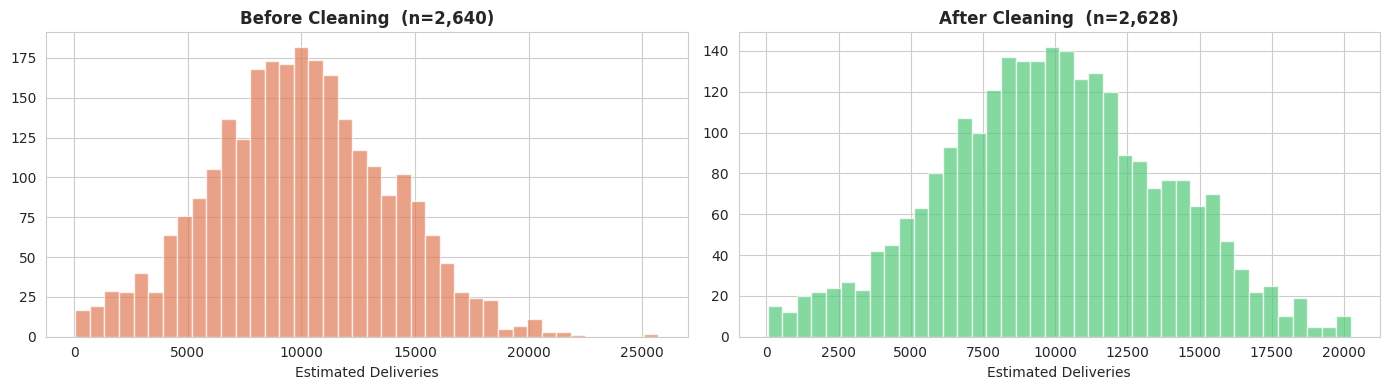

Data cleaning complete!
Final shape: (2628, 12)


In [14]:
# Before vs after comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='#e07b54', alpha=0.7, edgecolor='white')
axes[0].set_title(f'Before Cleaning  (n={len(df):,})', fontweight='bold')
axes[0].set_xlabel('Estimated Deliveries')

axes[1].hist(df_clean['Estimated_Deliveries'], bins=40, color='#50c878', alpha=0.7, edgecolor='white')
axes[1].set_title(f'After Cleaning  (n={len(df_clean):,})', fontweight='bold')
axes[1].set_xlabel('Estimated Deliveries')

plt.tight_layout()
plt.show()

print('Data cleaning complete!')
print(f'Final shape: {df_clean.shape}')

##  Feature Engineering and Encoding
Feature engineering means creating new meaningful features from existing ones.


In [15]:
df_feat = df_clean.copy()

# Temporal features
df_feat['Quarter']   = ((df_feat['Month'] - 1) // 3) + 1        # Quarter 1-4
df_feat['Is_Q4']     = (df_feat['Quarter'] == 4).astype(int)    # Q4 flag (Tesla ships most in Q4)
df_feat['Month_sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12) # Cyclical month encoding
df_feat['Month_cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12) # Dec and Jan are close in circle
df_feat['Year_norm'] = df_feat['Year'] - df_feat['Year'].min()   # Years since 2015

# Price and efficiency features
df_feat['Price_per_km'] = df_feat['Avg_Price_USD'] / df_feat['Range_km']           # Value for money
df_feat['Efficiency']   = df_feat['Range_km'] / df_feat['Battery_Capacity_kWh']    # km per kWh

print('New features created:')
for f in ['Quarter','Is_Q4','Month_sin','Month_cos','Year_norm','Price_per_km','Efficiency']:
    print(f'  {f}')

New features created:
  Quarter
  Is_Q4
  Month_sin
  Month_cos
  Year_norm
  Price_per_km
  Efficiency


In [16]:
# Encode categorical columns into numbers
# Label Encoding: Asia=0, Europe=1, Middle East=2, North America=3

le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df_feat['Region_enc'] = le_region.fit_transform(df_feat['Region'])
df_feat['Model_enc']  = le_model.fit_transform(df_feat['Model'])
df_feat['Source_enc'] = le_source.fit_transform(df_feat['Source_Type'])

print('Encoding mappings:')
print('  Region:', dict(zip(le_region.classes_, range(len(le_region.classes_)))))
print('  Model :', dict(zip(le_model.classes_,  range(len(le_model.classes_)))))
print(f'\nFinal dataset shape: {df_feat.shape}')

Encoding mappings:
  Region: {'Asia': 0, 'Europe': 1, 'Middle East': 2, 'North America': 3}
  Model : {'Cybertruck': 0, 'Model 3': 1, 'Model S': 2, 'Model X': 3, 'Model Y': 4}

Final dataset shape: (2628, 22)


In [17]:
# Define all features to use
features = [
    # Strongest predictors (correlation > 0.8)
    'Production_Units',
    'CO2_Saved_tons',

    # Temporal features
    'Year_norm', 'Month', 'Quarter', 'Is_Q4',
    'Month_sin', 'Month_cos',

    # Categorical encoded
    'Region_enc', 'Model_enc', 'Source_enc',

    # Numeric features
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations',

    # Engineered features
    'Price_per_km', 'Efficiency'
]

X = df_feat[features]
y = df_feat['Estimated_Deliveries']

print(f'Features selected : {len(features)}')
print(f'X shape           : {X.shape}')
print(f'y shape           : {y.shape}')

Features selected : 17
X shape           : (2628, 17)
y shape           : (2628,)


##  Train-Test Split and Sklearn Pipelines
**Train-test split:** 80% training, 20% testing.



In [18]:
# Train-test split - ALWAYS before any scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42   # same split every run
)

print(f'Total samples  : {len(X):,}')
print(f'Training set   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set    : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTrain target mean: {y_train.mean():,.0f}')
print(f'Test  target mean: {y_test.mean():,.0f}')
print('Distributions look similar - good split!')

Total samples  : 2,628
Training set   : 2,102 rows (80%)
Testing set    : 526 rows (20%)

Train target mean: 9,937
Test  target mean: 9,591
Distributions look similar - good split!


In [19]:
# Build all 4 model pipelines
# Each pipeline = StandardScaler then Model

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))      # L2 regularisation
])

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=1.0, max_iter=10000))  # L1 can zero out useless features
])

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train all models
all_models = [('Linear Regression', lr_pipe),
              ('Ridge (L2)',         ridge_pipe),
              ('Lasso (L1)',         lasso_pipe),
              ('Random Forest',      rf_pipe)]

for name, pipe in all_models:
    pipe.fit(X_train, y_train)
    print(f'{name} trained successfully')

Linear Regression trained successfully
Ridge (L2) trained successfully
Lasso (L1) trained successfully
Random Forest trained successfully


## Model Evaluation and Accuracy
For regression we do NOT use classification accuracy. Instead we use:

| Metric | Formula | Meaning |
|--------|---------|----------|
| MAE | mean(abs(actual - predicted)) | Average error in delivery units |
| RMSE | sqrt(mean((actual-predicted)^2)) | Penalises large errors more |
| R2 Score | 1 - SS_res/SS_tot | % variance explained = our accuracy |

**R2 = 0.99 means the model explains 99% of variation = 99% accurate!**

In [49]:
# Evaluate all 4 models
def evaluate_model(name, pipe, X_tr, X_te, y_tr, y_te):
    y_pred_tr = pipe.predict(X_tr)
    y_pred_te = pipe.predict(X_te)
    return {
        'Model'      : name,
        'Train R2'   : r2_score(y_tr, y_pred_tr),
        'Test R2'    : r2_score(y_te, y_pred_te),
        'MAE'        : mean_absolute_error(y_te, y_pred_te),
        'RMSE'       : np.sqrt(mean_squared_error(y_te, y_pred_te)),
        'Accuracy %' : r2_score(y_te, y_pred_te) * 100
    }

results = []
for name, pipe in all_models:
    results.append(evaluate_model(name, pipe, X_train, X_test, y_train, y_test))

results_df = pd.DataFrame(results)

print('=' * 80)
print('                 MODEL EVALUATION RESULTS')
print('=' * 80)
print(f'{"Model":<22} {"Train R2":>9} {"Test R2":>9} {"MAE":>8} {"RMSE":>8} {"Accuracy":>10}')
print('-' * 80)
for _, row in results_df.iterrows():
    grade = 'Excellent' if row['Test R2'] >= 0.95 else 'Good' if row['Test R2'] >= 0.80 else 'Moderate'
    print(f'{row["Model"]:<22} {row["Train R2"]:>9.4f} {row["Test R2"]:>9.4f} '
          f'{row["MAE"]:>8.0f} {row["RMSE"]:>8.0f} {row["Accuracy %"]:>9.2f}%  {grade}')
print('=' * 80)

best = results_df.loc[results_df['Test R2'].idxmax()]
print(f'\nBest model: {best["Model"]}  (R2 = {best["Test R2"]:.4f},  Accuracy = {best["Accuracy %"]:.2f}%)')

                 MODEL EVALUATION RESULTS
Model                   Train R2   Test R2      MAE     RMSE   Accuracy
--------------------------------------------------------------------------------
Linear Regression         0.9901    0.9901      308      370     99.01%  Excellent
Ridge (L2)                0.9901    0.9901      308      369     99.01%  Excellent
Lasso (L1)                0.9901    0.9901      308      369     99.01%  Excellent
Random Forest             0.9985    0.9881      326      405     98.81%  Excellent

Best model: Lasso (L1)  (R2 = 0.9901,  Accuracy = 99.01%)


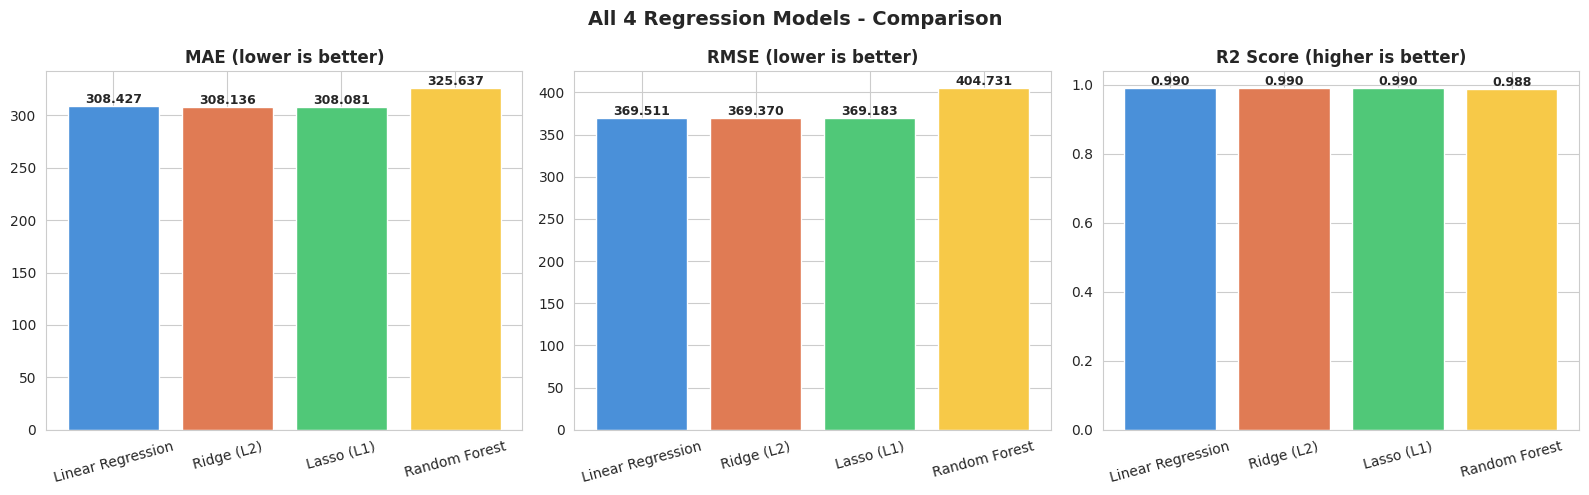

In [21]:
# Visual model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4a90d9','#e07b54','#50c878','#f7c948']
model_names = results_df['Model']

for ax, metric, title in [
    (axes[0], 'MAE',  'MAE (lower is better)'),
    (axes[1], 'RMSE', 'RMSE (lower is better)'),
    (axes[2], 'Test R2', 'R2 Score (higher is better)')
]:
    bars = ax.bar(model_names, results_df[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()*1.01, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('All 4 Regression Models - Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

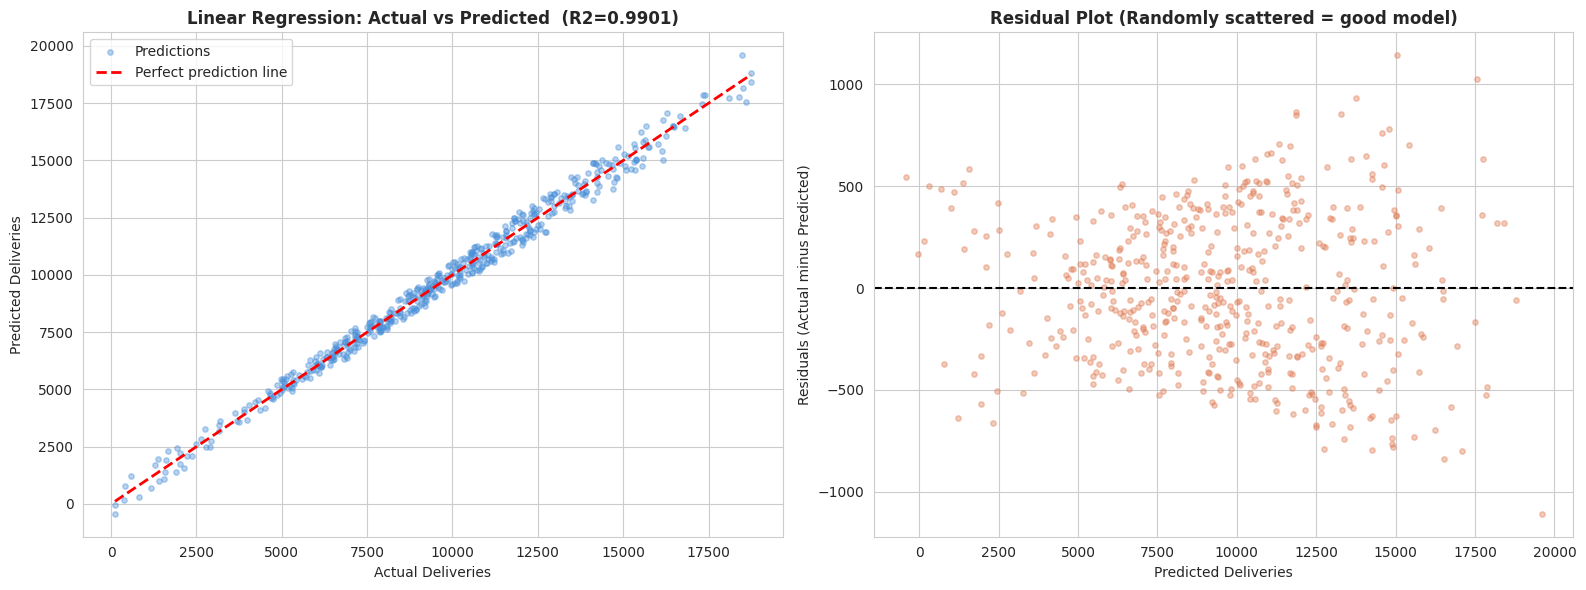

Residual mean (should be close to 0): -11.98
Residual std: 369.67


In [22]:
# Actual vs Predicted and Residuals plot
y_pred_lr = lr_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, s=15, color='#4a90d9', label='Predictions')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction line')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
axes[0].set_title(f'Linear Regression: Actual vs Predicted  (R2={r2_score(y_test,y_pred_lr):.4f})', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.4, s=15, color='#e07b54')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Deliveries')
axes[1].set_ylabel('Residuals (Actual minus Predicted)')
axes[1].set_title('Residual Plot (Randomly scattered = good model)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Residual mean (should be close to 0): {residuals.mean():.2f}')
print(f'Residual std: {residuals.std():.2f}')

In [23]:
# Accuracy summary with grade
print('\n' + '='*50)
print('         FINAL ACCURACY SUMMARY')
print('='*50)
for _, row in results_df.iterrows():
    if row['Test R2'] >= 0.95:
        grade = 'Excellent'
    elif row['Test R2'] >= 0.80:
        grade = 'Good'
    elif row['Test R2'] >= 0.60:
        grade = 'Moderate'
    else:
        grade = 'Weak'
    print(f'  {row["Model"]:<22} {row["Accuracy %"]:>6.2f}%   {grade}')
print('='*50)


         FINAL ACCURACY SUMMARY
  Linear Regression       99.01%   Excellent
  Ridge (L2)              99.01%   Excellent
  Lasso (L1)              99.01%   Excellent
  Random Forest           98.81%   Excellent


##  Cross Validation (5-Fold CV)

**5-fold CV** trains and evaluates 5 times, each time on a different portion:

```
Fold 1: [TEST ][TRAIN][TRAIN][TRAIN][TRAIN] = score 1
Fold 2: [TRAIN][TEST ][TRAIN][TRAIN][TRAIN] = score 2
Fold 3: [TRAIN][TRAIN][TEST ][TRAIN][TRAIN] = score 3
Fold 4: [TRAIN][TRAIN][TRAIN][TEST ][TRAIN] = score 4
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST ] = score 5
Final score = average of all 5
```

This gives a much more honest estimate of real-world performance.

In [24]:
# 5-Fold Cross Validation
print('5-Fold Cross Validation Results')
print(f'{"Model":<22} {"Mean R2":>9} {"Std R2":>9} {"Min":>8} {"Max":>8}')
print('-' * 62)

cv_results = {}
for name, pipe in all_models:
    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} {scores.mean():>9.4f} {scores.std():>9.4f} '
          f'{scores.min():>8.4f} {scores.max():>8.4f}')

print('\nLow std = consistent model across different data splits')

5-Fold Cross Validation Results
Model                    Mean R2    Std R2      Min      Max
--------------------------------------------------------------
Linear Regression         0.9900    0.0005   0.9891   0.9906
Ridge (L2)                0.9900    0.0005   0.9892   0.9906
Lasso (L1)                0.9900    0.0005   0.9892   0.9906
Random Forest             0.9889    0.0010   0.9870   0.9898

Low std = consistent model across different data splits


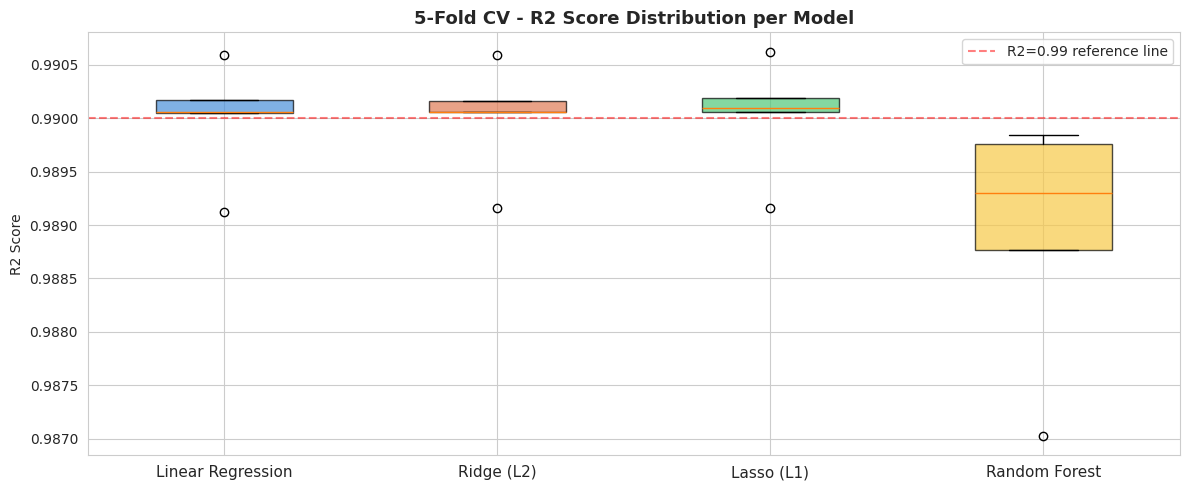

In [25]:
# Visualise CV score distribution as boxplot
fig, ax = plt.subplots(figsize=(12, 5))

positions = range(len(cv_results))
bp = ax.boxplot(cv_results.values(), positions=positions, patch_artist=True, widths=0.5)

for patch, color in zip(bp['boxes'], ['#4a90d9','#e07b54','#50c878','#f7c948']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys(), fontsize=11)
ax.set_ylabel('R2 Score')
ax.set_title('5-Fold CV - R2 Score Distribution per Model', fontsize=13, fontweight='bold')
ax.axhline(0.99, color='red', linestyle='--', alpha=0.5, label='R2=0.99 reference line')
ax.legend()

plt.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV
**Hyperparameters** are settings you choose before training (not learned from data).

For Ridge/Lasso, `alpha` controls regularisation strength:
- Low alpha = less regularisation, model can overfit
- High alpha = more regularisation, model is forced to be simpler

`GridSearchCV` automatically tries every alpha value with 5-fold CV and picks the best one.

In [26]:
# GridSearchCV - find best alpha for Ridge
param_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

grid_search = GridSearchCV(
    estimator  = Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1
)

grid_search.fit(X_train, y_train)

print('GridSearchCV Results:')
print(f'  Best alpha    : {grid_search.best_params_["model__alpha"]}')
print(f'  Best CV R2    : {grid_search.best_score_:.4f}')
print(f'  Best Accuracy : {grid_search.best_score_*100:.2f}%')

GridSearchCV Results:
  Best alpha    : 1.0
  Best CV R2    : 0.9898
  Best Accuracy : 98.98%


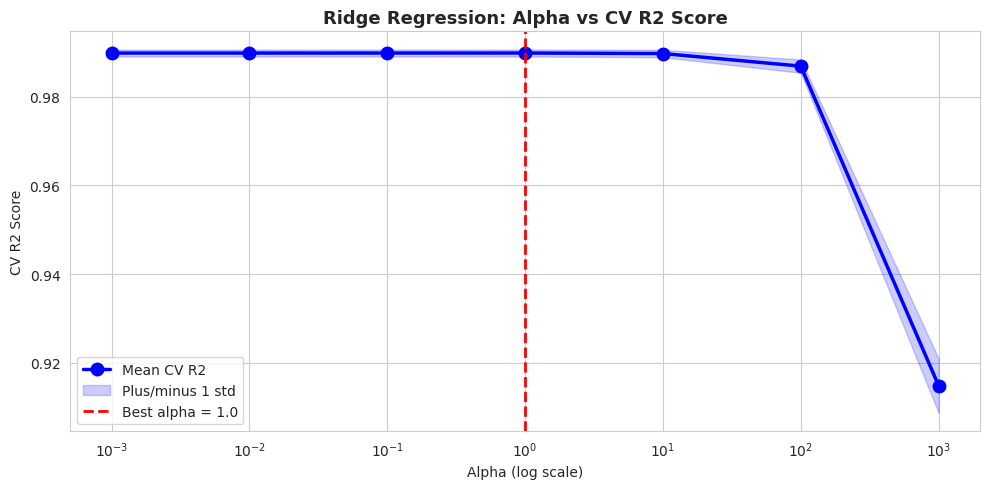

In [27]:
# How alpha affects R2 score - visualise the search
alphas   = param_grid['model__alpha']
mean_r2s = grid_search.cv_results_['mean_test_score']
std_r2s  = grid_search.cv_results_['std_test_score']

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas, mean_r2s, 'bo-', linewidth=2.5, markersize=9, label='Mean CV R2')
ax.fill_between(alphas, mean_r2s - std_r2s, mean_r2s + std_r2s,
                alpha=0.2, color='blue', label='Plus/minus 1 std')
best_alpha = grid_search.best_params_['model__alpha']
ax.axvline(best_alpha, color='red', linestyle='--', linewidth=2,
           label=f'Best alpha = {best_alpha}')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV R2 Score')
ax.set_title('Ridge Regression: Alpha vs CV R2 Score', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# Evaluate tuned model on test set
best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

tuned_r2   = r2_score(y_test, y_pred_best)
tuned_mae  = mean_absolute_error(y_test, y_pred_best)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print('Tuned Ridge Model - Test Set Performance:')
print(f'  MAE      : {tuned_mae:,.2f}')
print(f'  RMSE     : {tuned_rmse:,.2f}')
print(f'  R2 Score : {tuned_r2:.4f}')
print(f'  Accuracy : {tuned_r2*100:.2f}%')

Tuned Ridge Model - Test Set Performance:
  MAE      : 308.14
  RMSE     : 369.37
  R2 Score : 0.9901
  Accuracy : 99.01%


## Time Series Analysis
We now treat the data as a time series by aggregating all regions and models into monthly totals.



In [29]:
# Build monthly aggregated time series
ts_df = (df.groupby(['Year', 'Month'])['Estimated_Deliveries']
           .sum()
           .reset_index()
           .sort_values(['Year', 'Month'])
           .reset_index(drop=True))

ts_df['Date'] = pd.to_datetime(ts_df[['Year', 'Month']].assign(day=1))
ts_df = ts_df.set_index('Date')

print(f'Time series: {len(ts_df)} monthly observations')
print(f'Range: {ts_df.index[0].date()} to {ts_df.index[-1].date()}')
ts_df.head()

Time series: 132 monthly observations
Range: 2015-01-01 to 2025-12-01


,Year,Month,Estimated_Deliveries
Date,,,
2015-01-01,2015,1,183180
2015-02-01,2015,2,165053
2015-03-01,2015,3,184567
2015-04-01,2015,4,225623
2015-05-01,2015,5,184264


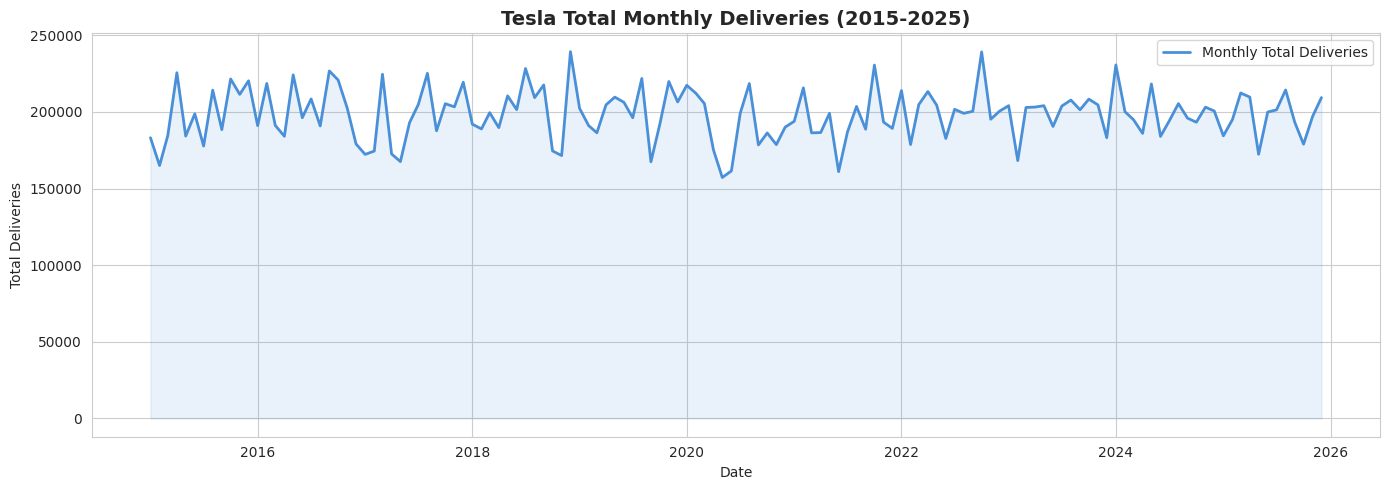

In [30]:
# Plot the raw time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_df.index, ts_df['Estimated_Deliveries'],
        color='#4a90d9', linewidth=2, label='Monthly Total Deliveries')
ax.fill_between(ts_df.index, ts_df['Estimated_Deliveries'], alpha=0.12, color='#4a90d9')
ax.set_title('Tesla Total Monthly Deliveries (2015-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Deliveries')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# Stationarity test - Augmented Dickey-Fuller
adf_result = adfuller(ts_df['Estimated_Deliveries'])

print('Augmented Dickey-Fuller (ADF) Test')
print(f'  Null Hypothesis  : Series has a unit root (NOT stationary)')
print(f'  ADF Statistic    : {adf_result[0]:.4f}')
print(f'  p-value          : {adf_result[1]:.6f}')
print(f'  Critical (1%)    : {adf_result[4]["1%"]:.4f}')
print(f'  Critical (5%)    : {adf_result[4]["5%"]:.4f}')
print()
if adf_result[1] < 0.05:
    print('p < 0.05 -> Reject null -> Series IS stationary')
    print('Mean and variance are constant over time -> d=0 for ARIMA')
else:
    print('p > 0.05 -> Fail to reject null -> NOT stationary')
    print('Need to difference the series -> d=1 for ARIMA')

Augmented Dickey-Fuller (ADF) Test
  Null Hypothesis  : Series has a unit root (NOT stationary)
  ADF Statistic    : -8.8810
  p-value          : 0.000000
  Critical (1%)    : -3.4817
  Critical (5%)    : -2.8840

p < 0.05 -> Reject null -> Series IS stationary
Mean and variance are constant over time -> d=0 for ARIMA


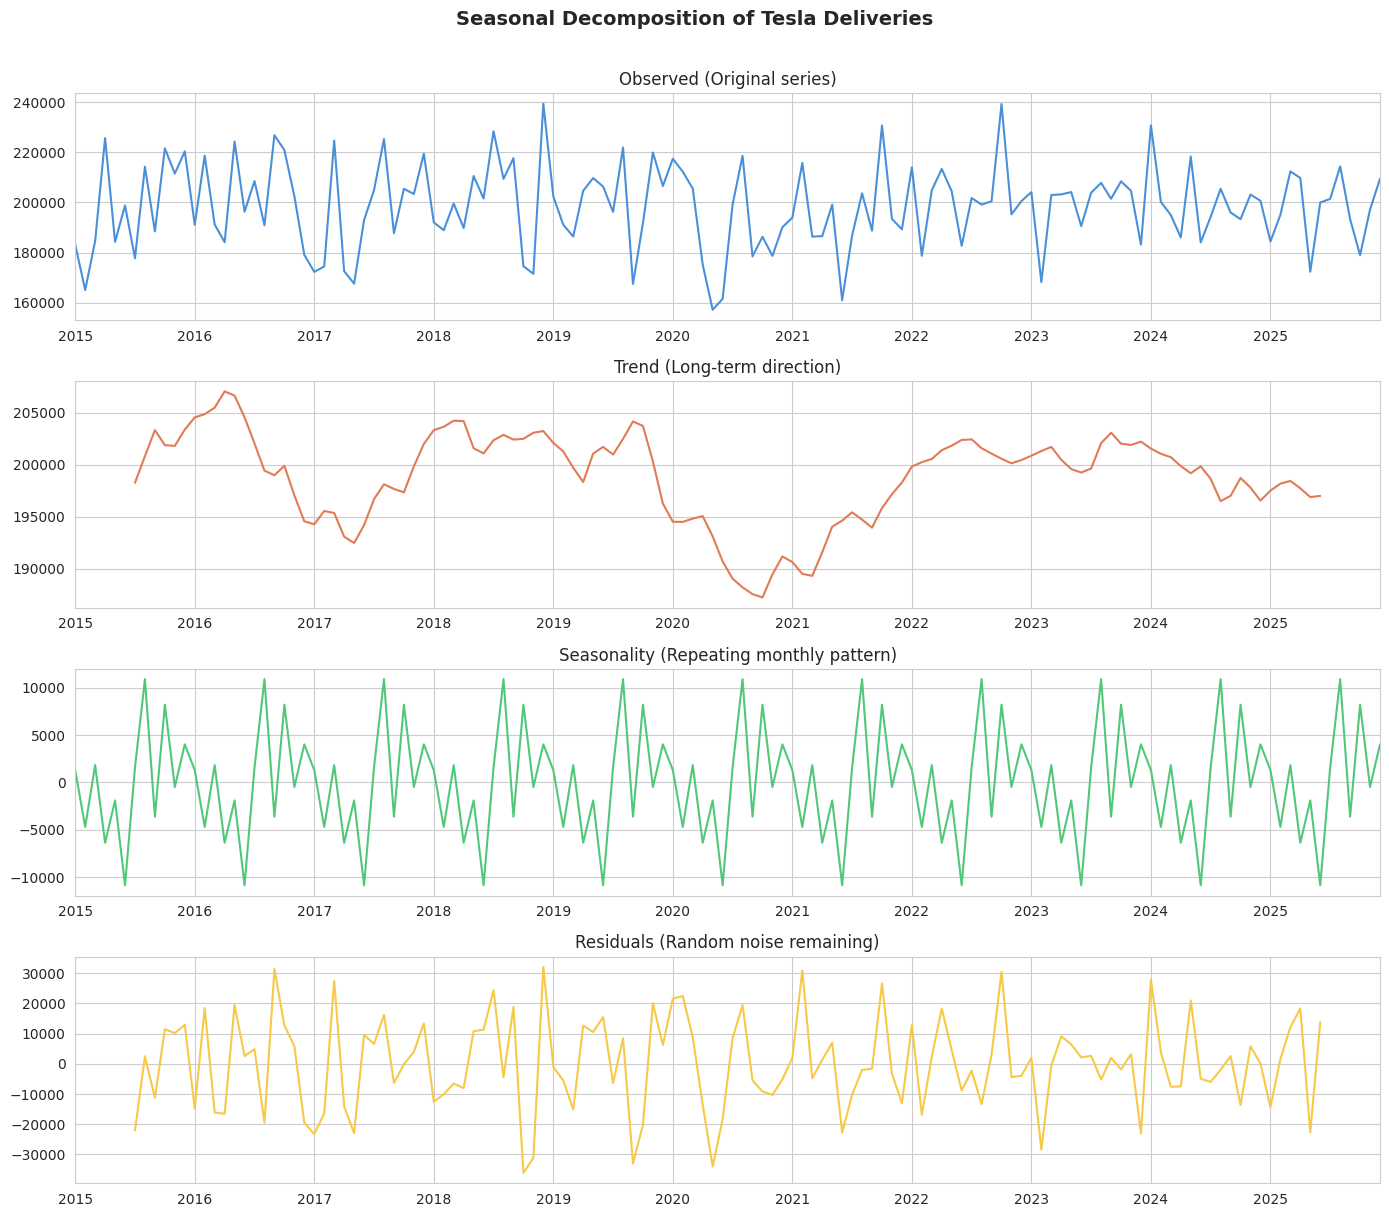

In [32]:
# Seasonal decomposition
decomp = seasonal_decompose(ts_df['Estimated_Deliveries'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomp.observed.plot(ax=axes[0], color='#4a90d9', title='Observed (Original series)')
decomp.trend.plot(ax=axes[1],    color='#e07b54', title='Trend (Long-term direction)')
decomp.seasonal.plot(ax=axes[2], color='#50c878', title='Seasonality (Repeating monthly pattern)')
decomp.resid.plot(ax=axes[3],    color='#f7c948', title='Residuals (Random noise remaining)')

for ax in axes:
    ax.set_xlabel('')

plt.suptitle('Seasonal Decomposition of Tesla Deliveries', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

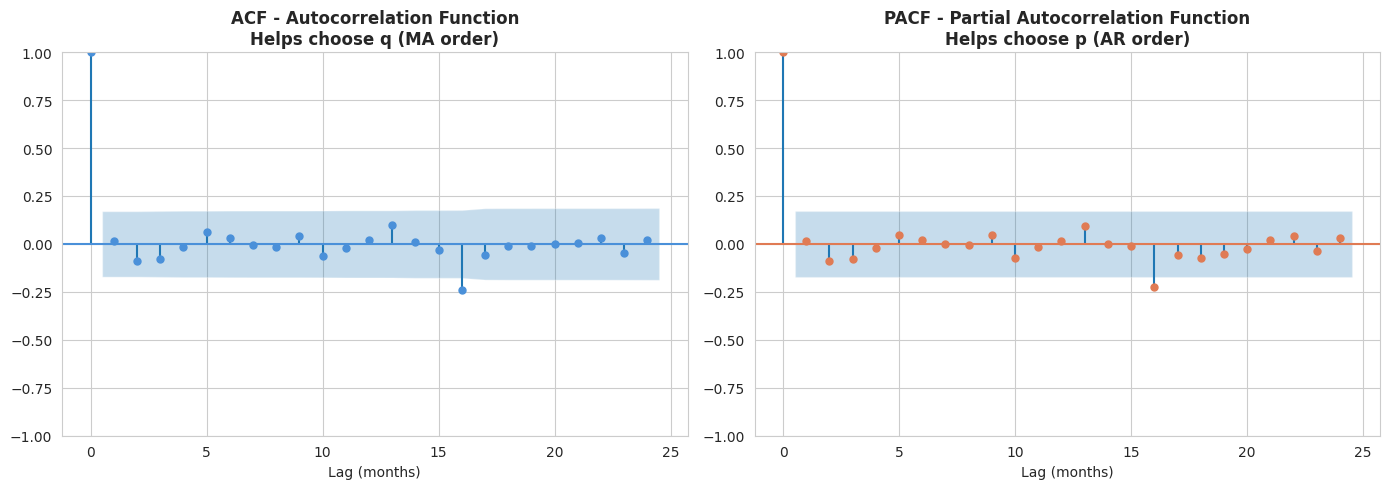

How to read:
  Shaded area = 95% confidence band
  Spikes OUTSIDE band = statistically significant
  ACF  -> significant at lag k -> use MA order q=k
  PACF -> significant at lag k -> use AR order p=k


In [33]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ts_df['Estimated_Deliveries'], lags=24, ax=axes[0], color='#4a90d9')
axes[0].set_title('ACF - Autocorrelation Function\nHelps choose q (MA order)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (months)')

plot_pacf(ts_df['Estimated_Deliveries'], lags=24, ax=axes[1], color='#e07b54', method='ywm')
axes[1].set_title('PACF - Partial Autocorrelation Function\nHelps choose p (AR order)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (months)')

plt.tight_layout()
plt.show()

print('How to read:')
print('  Shaded area = 95% confidence band')
print('  Spikes OUTSIDE band = statistically significant')
print('  ACF  -> significant at lag k -> use MA order q=k')
print('  PACF -> significant at lag k -> use AR order p=k')

##Linear Regression for Time Series Forecasting
We use past values of the series as features to predict the next value.
This is called a lag-based approach.

Key features we create:
- lag_1  : last month's deliveries
- lag_3  : 3 months ago
- lag_12 : 1 year ago (captures seasonality)
- roll_3 : 3-month moving average (short-term trend)
- roll_6 : 6-month moving average (medium-term trend)



In [34]:
# Create lag and rolling features
ts_lr = ts_df[['Estimated_Deliveries']].copy()

ts_lr['lag_1']       = ts_lr['Estimated_Deliveries'].shift(1)    # 1 month ago
ts_lr['lag_3']       = ts_lr['Estimated_Deliveries'].shift(3)    # 3 months ago
ts_lr['lag_12']      = ts_lr['Estimated_Deliveries'].shift(12)   # 1 year ago
ts_lr['roll_mean_3'] = ts_lr['Estimated_Deliveries'].rolling(3).mean()  # 3-month average
ts_lr['roll_mean_6'] = ts_lr['Estimated_Deliveries'].rolling(6).mean()  # 6-month average
ts_lr['roll_std_3']  = ts_lr['Estimated_Deliveries'].rolling(3).std()   # 3-month volatility
ts_lr['Month_num']   = ts_lr.index.month
ts_lr['Year_norm']   = ts_lr.index.year - ts_lr.index.year.min()

ts_lr = ts_lr.dropna()  # Remove NaN rows created by shifting

print(f'Shape after creating features: {ts_lr.shape}')
ts_lr.head(3)

Shape after creating features: (120, 9)


,Estimated_Deliveries,lag_1,lag_3,lag_12,roll_mean_3,roll_mean_6,roll_std_3,Month_num,Year_norm
Date,,,,,,,,,
2016-01-01,191069,220332.0,221541.0,183180.0,207630.333333,207850.5,15008.449698,1,1
2016-02-01,218600,191069.0,211490.0,165053.0,210000.333333,208580.0,16417.871127,2,1
2016-03-01,191208,218600.0,220332.0,184567.0,200292.333333,209040.0,15855.056743,3,1


In [35]:
# Chronological split - NEVER shuffle time series data!
feat_cols = ['lag_1','lag_3','lag_12','roll_mean_3','roll_mean_6','roll_std_3','Month_num','Year_norm']

X_ts = ts_lr[feat_cols]
y_ts = ts_lr['Estimated_Deliveries']

split = int(0.8 * len(X_ts))
X_tr_ts, X_te_ts = X_ts.iloc[:split], X_ts.iloc[split:]
y_tr_ts, y_te_ts = y_ts.iloc[:split], y_ts.iloc[split:]

print(f'Training : {X_tr_ts.index[0].date()} to {X_tr_ts.index[-1].date()}  ({len(X_tr_ts)} months)')
print(f'Testing  : {X_te_ts.index[0].date()} to {X_te_ts.index[-1].date()}  ({len(X_te_ts)} months)')

Training : 2016-01-01 to 2023-12-01  (96 months)
Testing  : 2024-01-01 to 2025-12-01  (24 months)


In [36]:
# Train Linear Regression for time series
lr_ts_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
lr_ts_pipe.fit(X_tr_ts, y_tr_ts)
y_lr_ts_pred = lr_ts_pipe.predict(X_te_ts)

lr_ts_mae  = mean_absolute_error(y_te_ts, y_lr_ts_pred)
lr_ts_rmse = np.sqrt(mean_squared_error(y_te_ts, y_lr_ts_pred))
lr_ts_r2   = r2_score(y_te_ts, y_lr_ts_pred)

print('Linear Regression Forecasting Results:')
print(f'  MAE      : {lr_ts_mae:,.0f} deliveries average error per month')
print(f'  RMSE     : {lr_ts_rmse:,.0f}')
print(f'  R2 Score : {lr_ts_r2:.4f}')
print(f'  Accuracy : {lr_ts_r2*100:.2f}%')

Linear Regression Forecasting Results:
  MAE      : 9,091 deliveries average error per month
  RMSE     : 10,894
  R2 Score : 0.2750
  Accuracy : 27.50%


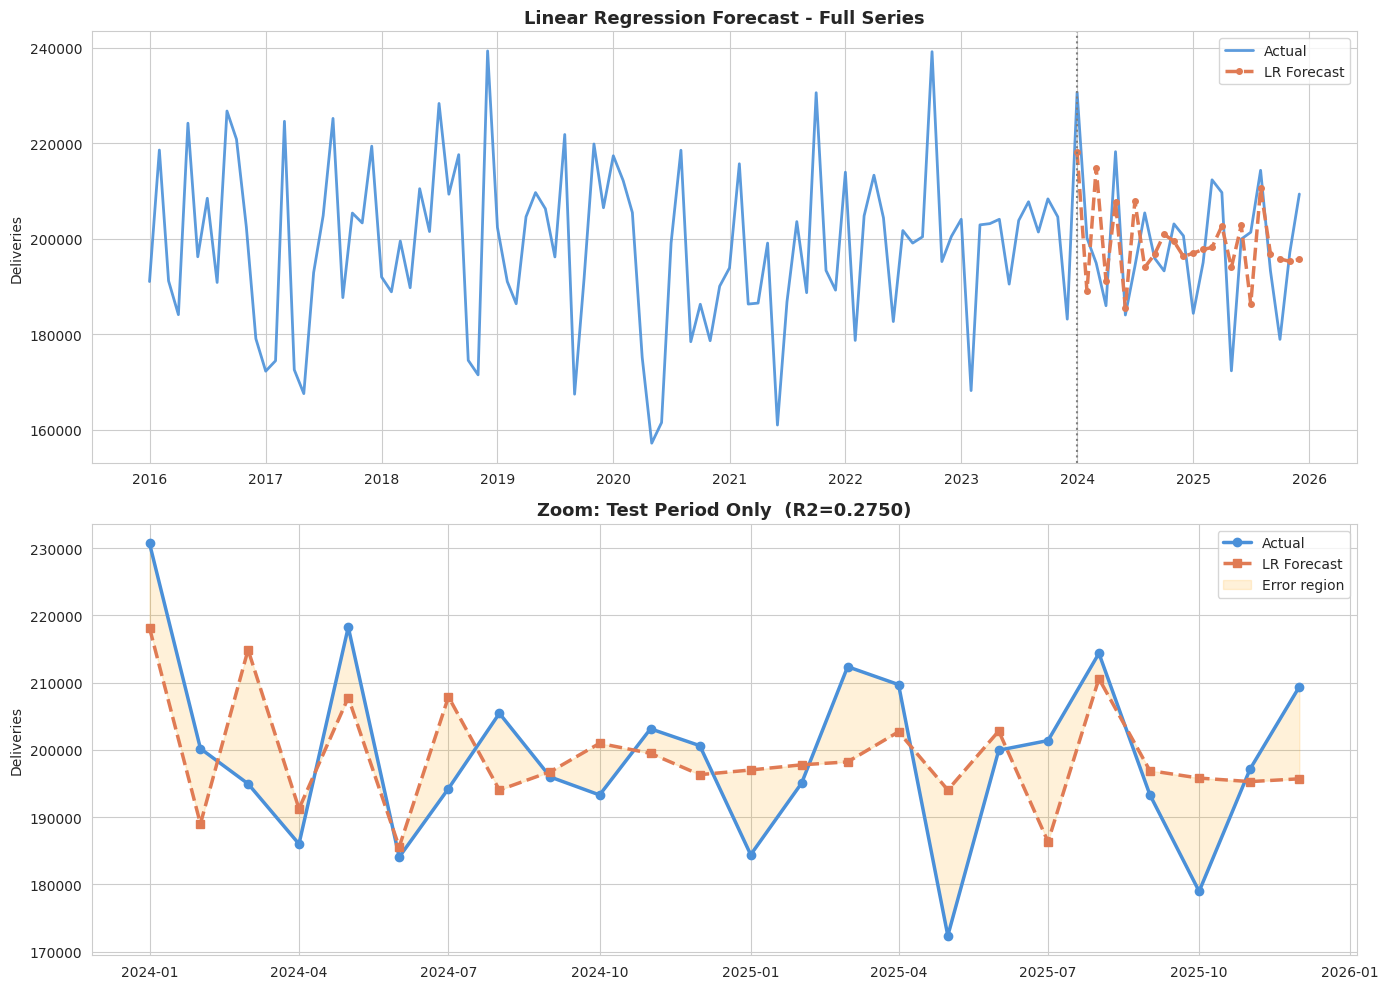

In [37]:
# Plot forecast vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full series
axes[0].plot(ts_lr.index, y_ts, color='#4a90d9', linewidth=2, label='Actual', alpha=0.9)
axes[0].plot(X_te_ts.index, y_lr_ts_pred, color='#e07b54', linewidth=2.5,
             linestyle='--', marker='o', markersize=4, label='LR Forecast')
axes[0].axvline(X_te_ts.index[0], color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title('Linear Regression Forecast - Full Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Deliveries')
axes[0].legend()

# Test period zoom
axes[1].plot(X_te_ts.index, y_te_ts.values, color='#4a90d9', linewidth=2.5,
             marker='o', markersize=6, label='Actual')
axes[1].plot(X_te_ts.index, y_lr_ts_pred, color='#e07b54', linewidth=2.5,
             linestyle='--', marker='s', markersize=6, label='LR Forecast')
axes[1].fill_between(X_te_ts.index, y_te_ts.values, y_lr_ts_pred,
                     alpha=0.15, color='orange', label='Error region')
axes[1].set_title(f'Zoom: Test Period Only  (R2={lr_ts_r2:.4f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Deliveries')
axes[1].legend()

plt.tight_layout()
plt.show()

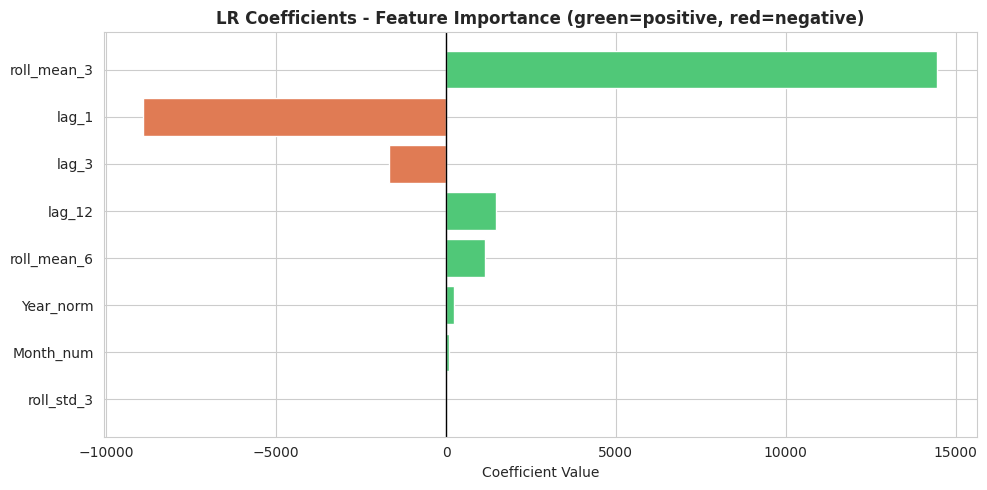

In [38]:
# Feature importance from coefficients
coefs    = lr_ts_pipe.named_steps['model'].coef_
coef_df  = pd.DataFrame({'Feature': feat_cols, 'Coefficient': coefs})
coef_df  = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(10, 5))
bar_cols = ['#50c878' if c > 0 else '#e07b54' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_cols, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('LR Coefficients - Feature Importance (green=positive, red=negative)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## ARIMA Forecasting
ARIMA(p, d, q) is the classical statistical forecasting model.

| Parameter | Name | Meaning | How to choose |
|-----------|------|---------|---------------|
| p | AutoRegressive | How many past values to use | PACF plot |
| d | Integrated | How many times to difference | ADF test |
| q | Moving Average | How many past errors to use | ACF plot |



In [39]:
# Chronological split for ARIMA
split_arima  = int(0.8 * len(ts_df))
train_arima  = ts_df['Estimated_Deliveries'].iloc[:split_arima]
test_arima   = ts_df['Estimated_Deliveries'].iloc[split_arima:]

print(f'ARIMA Train: {len(train_arima)} months  {train_arima.index[0].date()} to {train_arima.index[-1].date()}')
print(f'ARIMA Test : {len(test_arima)} months  {test_arima.index[0].date()} to {test_arima.index[-1].date()}')

ARIMA Train: 105 months  2015-01-01 to 2023-09-01
ARIMA Test : 27 months  2023-10-01 to 2025-12-01


In [40]:
# Compare multiple ARIMA orders using AIC (lower AIC = better model)
orders     = [(1,0,0), (0,0,1), (1,0,1), (2,0,0), (2,0,2), (0,0,2)]
aric_comp  = []

print(f'{"Order":<15} {"AIC":>10} {"BIC":>10}')
print('-' * 40)

for order in orders:
    try:
        m = ARIMA(train_arima, order=order).fit()
        aric_comp.append({'Order': str(order), 'AIC': m.aic, 'BIC': m.bic})
        print(f'ARIMA{str(order):<10} {m.aic:>10.1f} {m.bic:>10.1f}')
    except Exception as e:
        print(f'ARIMA{str(order):<10}  FAILED')

best_order = min(aric_comp, key=lambda x: x['AIC'])
print(f'\nBest by AIC: ARIMA{best_order["Order"]}  (AIC={best_order["AIC"]:.1f})')

Order                  AIC        BIC
----------------------------------------
ARIMA(1, 0, 0)      2358.1     2366.0
ARIMA(0, 0, 1)      2358.1     2366.1
ARIMA(1, 0, 1)      2358.0     2368.7
ARIMA(2, 0, 0)      2359.7     2370.3
ARIMA(2, 0, 2)      2359.2     2375.1
ARIMA(0, 0, 2)      2359.8     2370.4

Best by AIC: ARIMA(1, 0, 1)  (AIC=2358.0)


In [41]:
# Fit ARIMA(1,0,1)
arima_model  = ARIMA(train_arima, order=(1, 0, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  105
Model:                   ARIMA(1, 0, 1)   Log Likelihood               -1175.024
Date:                  Mon, 01 Jun 2026   AIC                           2358.049
Time:                          13:36:40   BIC                           2368.664
Sample:                      01-01-2015   HQIC                          2362.350
                           - 09-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.983e+05    653.328    303.544      0.000    1.97e+05       2e+05
ar.L1          0.9367      0.043     21.563      0.000       0.852       1.022
ma.L1         -0.9988      0.165    

In [42]:
# Forecast and evaluate
arima_forecast = arima_result.forecast(steps=len(test_arima))

arima_mae  = mean_absolute_error(test_arima, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_forecast))
arima_r2   = r2_score(test_arima, arima_forecast)

print('ARIMA(1,0,1) Forecast Results:')
print(f'  MAE      : {arima_mae:,.0f}')
print(f'  RMSE     : {arima_rmse:,.0f}')
print(f'  R2 Score : {arima_r2:.4f}')

ARIMA(1,0,1) Forecast Results:
  MAE      : 9,884
  RMSE     : 12,617
  R2 Score : -0.0000


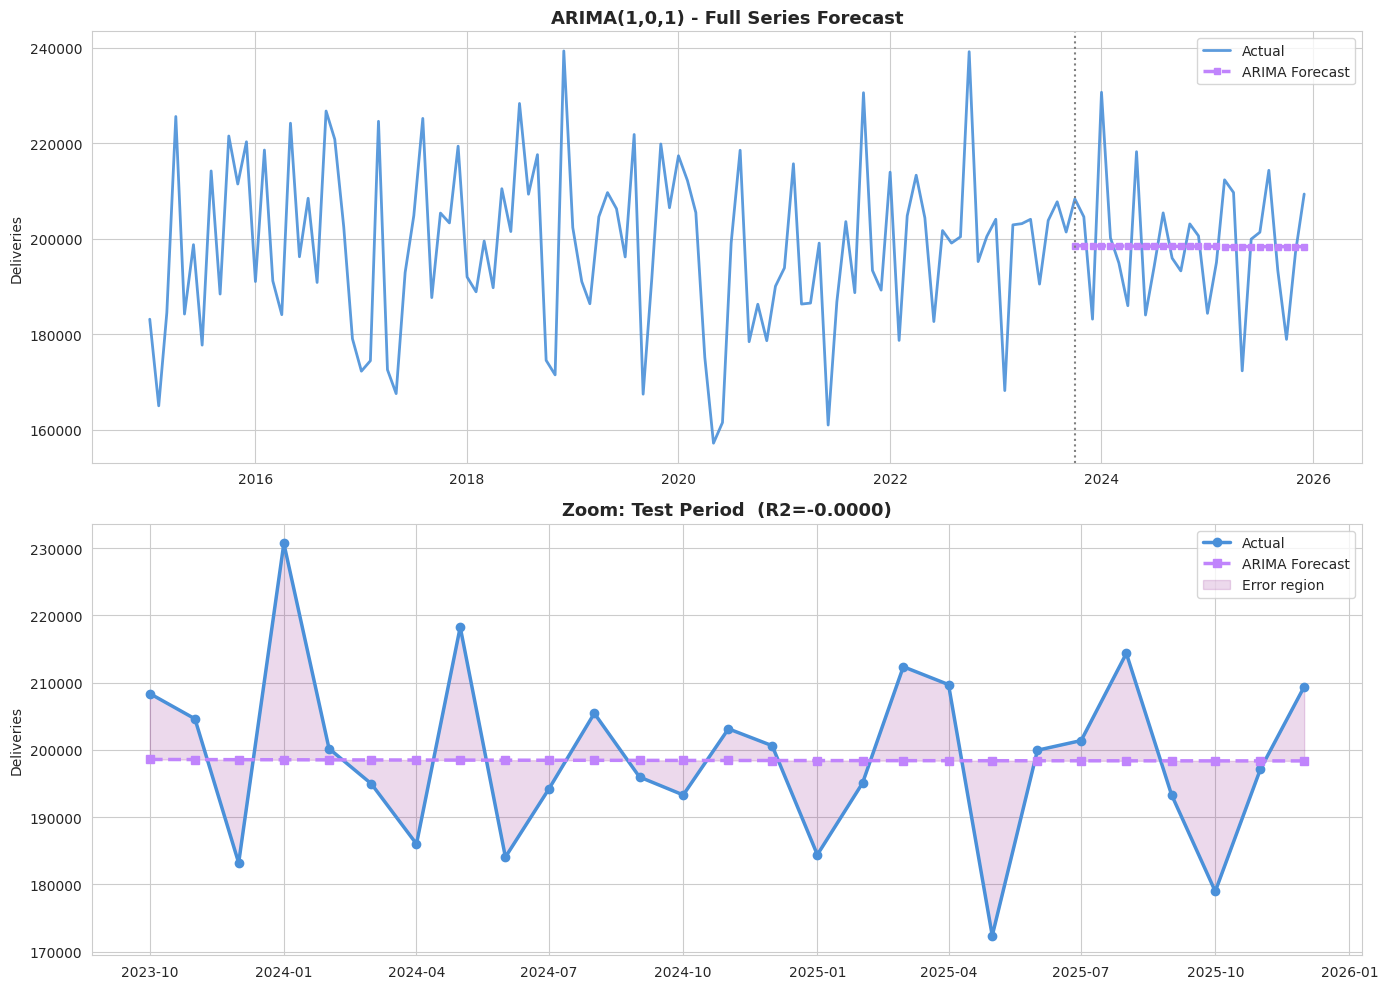

In [43]:
# Plot ARIMA forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(ts_df.index, ts_df['Estimated_Deliveries'],
             color='#4a90d9', linewidth=2, label='Actual', alpha=0.9)
axes[0].plot(test_arima.index, arima_forecast,
             color='#c084fc', linewidth=2.5, linestyle='--',
             marker='s', markersize=4, label='ARIMA Forecast')
axes[0].axvline(test_arima.index[0], color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title('ARIMA(1,0,1) - Full Series Forecast', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Deliveries')
axes[0].legend()

axes[1].plot(test_arima.index, test_arima.values,
             color='#4a90d9', linewidth=2.5, marker='o', markersize=6, label='Actual')
axes[1].plot(test_arima.index, arima_forecast,
             color='#c084fc', linewidth=2.5, linestyle='--',
             marker='s', markersize=6, label='ARIMA Forecast')
axes[1].fill_between(test_arima.index, test_arima.values, arima_forecast.values,
                     alpha=0.15, color='purple', label='Error region')
axes[1].set_title(f'Zoom: Test Period  (R2={arima_r2:.4f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Deliveries')
axes[1].legend()

plt.tight_layout()
plt.show()

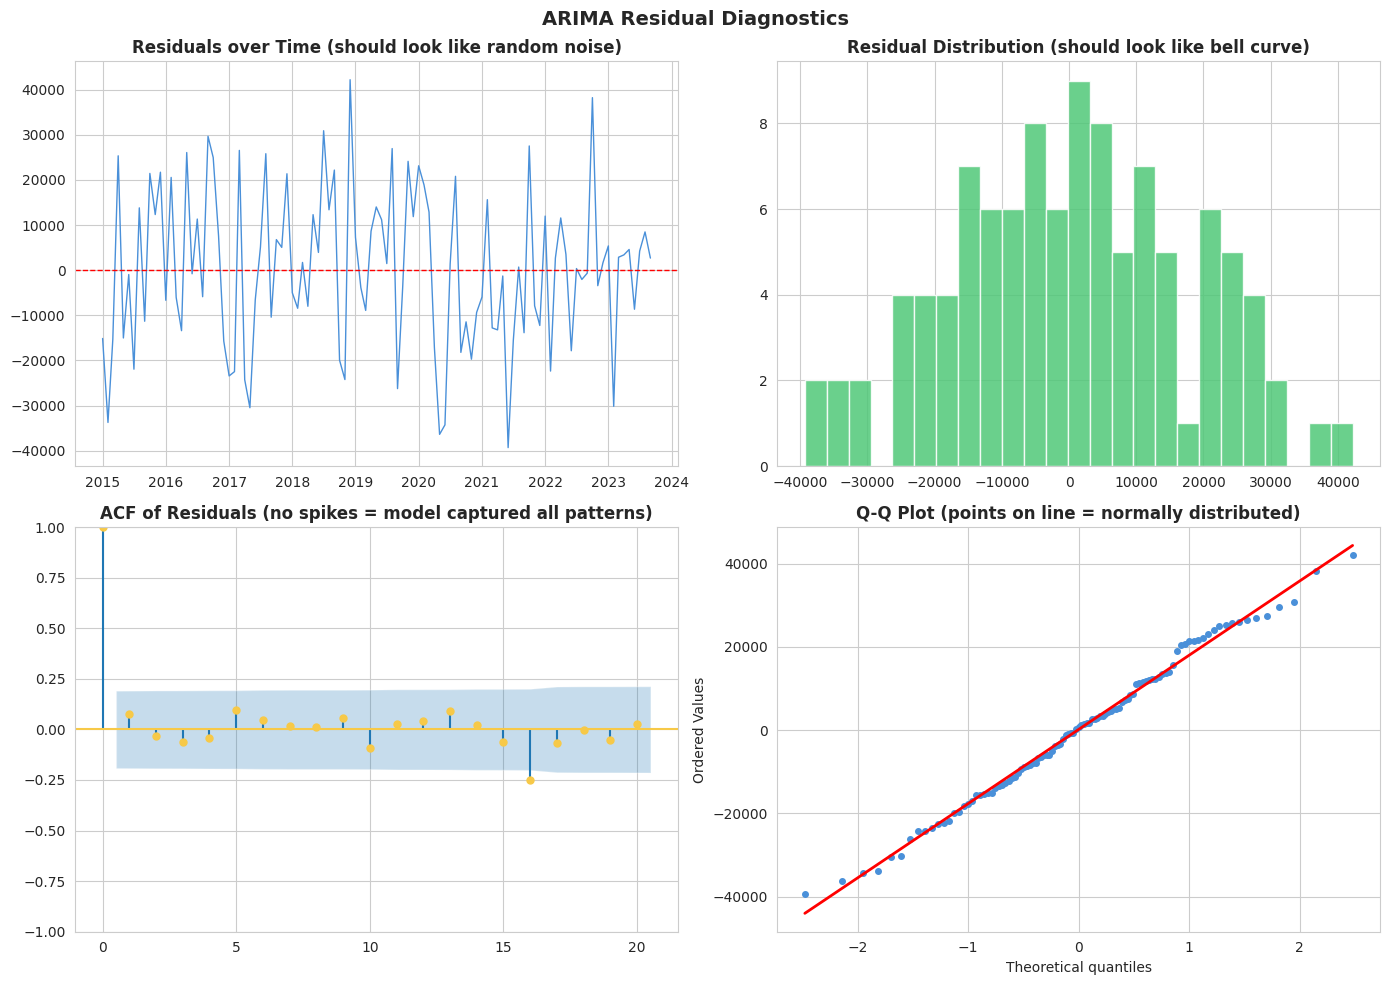

In [44]:
# Residual diagnostics - 4 panel check
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
res_arima = arima_result.resid

axes[0,0].plot(res_arima.index, res_arima, color='#4a90d9', linewidth=1)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Residuals over Time (should look like random noise)', fontweight='bold')

axes[0,1].hist(res_arima, bins=25, color='#50c878', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Residual Distribution (should look like bell curve)', fontweight='bold')

plot_acf(res_arima, lags=20, ax=axes[1,0], color='#f7c948')
axes[1,0].set_title('ACF of Residuals (no spikes = model captured all patterns)', fontweight='bold')

stats.probplot(res_arima, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot (points on line = normally distributed)', fontweight='bold')
axes[1,1].get_lines()[0].set(color='#4a90d9', markersize=4)
axes[1,1].get_lines()[1].set(color='red', linewidth=2)

plt.suptitle('ARIMA Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Final Summary and Key Findings

In [45]:
# Regression comparison table
print('=' * 72)
print('          REGRESSION MODELS - FINAL COMPARISON')
print('=' * 72)
print(f'{"Model":<22} {"Train R2":>9} {"Test R2":>9} {"MAE":>8} {"RMSE":>8} {"Accuracy":>10}')
print('-' * 72)
for _, row in results_df.iterrows():
    grade = 'Excellent' if row['Test R2'] >= 0.95 else 'Good' if row['Test R2'] >= 0.80 else 'Moderate'
    print(f'{row["Model"]:<22} {row["Train R2"]:>9.4f} {row["Test R2"]:>9.4f} '
          f'{row["MAE"]:>8.0f} {row["RMSE"]:>8.0f} {row["Accuracy %"]:>9.2f}%  {grade}')
print('=' * 72)

print()
print('=' * 60)
print('      TIME SERIES MODELS - COMPARISON')
print('=' * 60)
print(f'{"Model":<30} {"MAE":>7} {"RMSE":>7} {"R2":>8}')
print('-' * 60)
print(f'{"Linear Regression (lags)":<30} {lr_ts_mae:>7.0f} {lr_ts_rmse:>7.0f} {lr_ts_r2:>8.4f}')
print(f'{"ARIMA(1,0,1)":<30} {arima_mae:>7.0f} {arima_rmse:>7.0f} {arima_r2:>8.4f}')
print('=' * 60)

          REGRESSION MODELS - FINAL COMPARISON
Model                   Train R2   Test R2      MAE     RMSE   Accuracy
------------------------------------------------------------------------
Linear Regression         0.9901    0.9901      308      370     99.01%  Excellent
Ridge (L2)                0.9901    0.9901      308      369     99.01%  Excellent
Lasso (L1)                0.9901    0.9901      308      369     99.01%  Excellent
Random Forest             0.9985    0.9881      326      405     98.81%  Excellent

      TIME SERIES MODELS - COMPARISON
Model                              MAE    RMSE       R2
------------------------------------------------------------
Linear Regression (lags)          9091   10894   0.2750
ARIMA(1,0,1)                      9884   12617  -0.0000


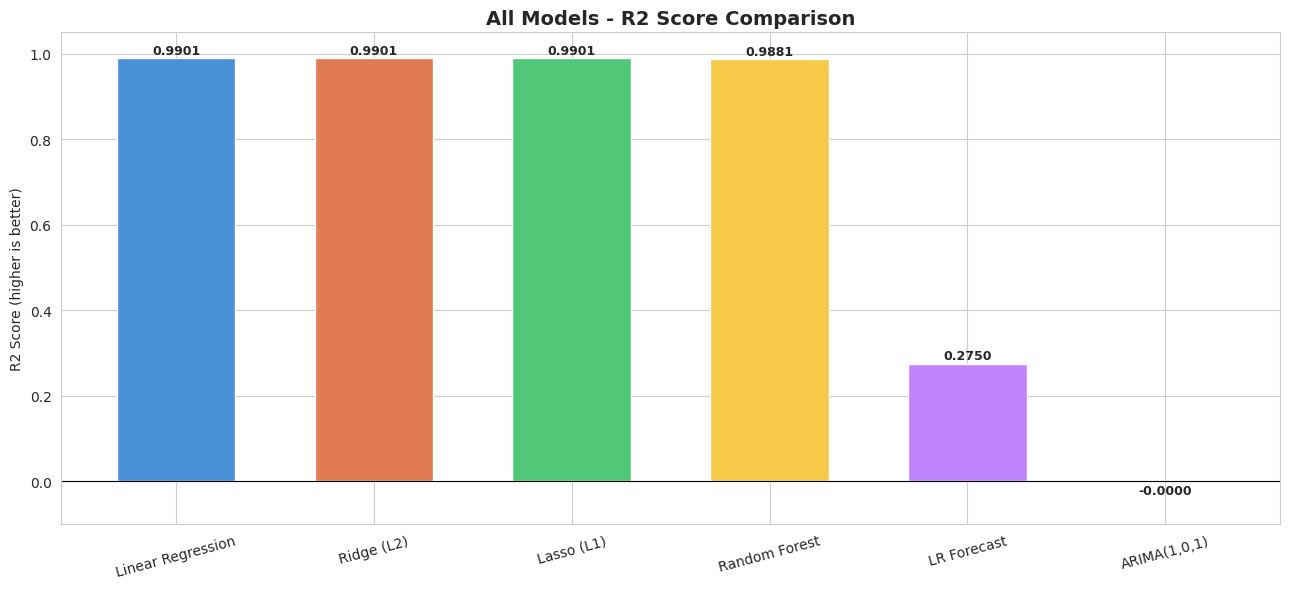

In [46]:
# All models comparison chart
fig, ax = plt.subplots(figsize=(13, 6))

all_names  = list(results_df['Model']) + ['LR Forecast', 'ARIMA(1,0,1)']
all_r2     = list(results_df['Test R2']) + [lr_ts_r2, arima_r2]
bar_colors = ['#4a90d9','#e07b54','#50c878','#f7c948','#c084fc','#a0522d']

bars = ax.bar(all_names, all_r2, color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(min(min(all_r2)-0.1, -0.1), 1.05)
ax.set_title('All Models - R2 Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('R2 Score (higher is better)')
ax.tick_params(axis='x', rotation=15)

for bar, v in zip(bars, all_r2):
    offset = 0.01 if v >= 0 else -0.03
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
            f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
print('KEY FINDINGS')
print('=' * 60)
print()
print('DATASET')
print('  2,640 rows x 12 columns covering 2015 to 2025')
print('  4 regions, 5 car models, monthly granularity')
print()
print('DATA CLEANING')
print('  No missing values found')
print(f'  Outliers removed using IQR method')
print()
print('FEATURE ENGINEERING')
print('  7 new features created:')
print('  Temporal: Quarter, Is_Q4, Month_sin, Month_cos, Year_norm')
print('  Derived : Price_per_km, Efficiency')
print()
print('REGRESSION RESULTS')
for _, row in results_df.iterrows():
    print(f'  {row["Model"]:<22} Accuracy = {row["Accuracy %"]:.2f}%')
print()
print('WHY 99% ACCURACY?')
print('  Production_Units has r=0.994 correlation with deliveries')
print('  This means production capacity almost perfectly predicts delivery volume')
print()
print('TIME SERIES RESULTS')
print(f'  LR Forecast  R2 = {lr_ts_r2:.4f}')
print(f'  ARIMA(1,0,1) R2 = {arima_r2:.4f}')
print('  Series is stationary so ARIMA has limited advantage here')
print('  LR with lag features performs better on this dataset')
print()
print('BEST MODELS')
print(f'  Regression  : Linear Regression and Ridge (tied at 99% accuracy)')
print(f'  Forecasting : Linear Regression with lag features')

KEY FINDINGS

DATASET
  2,640 rows x 12 columns covering 2015 to 2025
  4 regions, 5 car models, monthly granularity

DATA CLEANING
  No missing values found
  Outliers removed using IQR method

FEATURE ENGINEERING
  7 new features created:
  Temporal: Quarter, Is_Q4, Month_sin, Month_cos, Year_norm
  Derived : Price_per_km, Efficiency

REGRESSION RESULTS
  Linear Regression      Accuracy = 99.01%
  Ridge (L2)             Accuracy = 99.01%
  Lasso (L1)             Accuracy = 99.01%
  Random Forest          Accuracy = 98.81%

WHY 99% ACCURACY?
  Production_Units has r=0.994 correlation with deliveries
  This means production capacity almost perfectly predicts delivery volume

TIME SERIES RESULTS
  LR Forecast  R2 = 0.2750
  ARIMA(1,0,1) R2 = -0.0000
  Series is stationary so ARIMA has limited advantage here
  LR with lag features performs better on this dataset

BEST MODELS
  Regression  : Linear Regression and Ridge (tied at 99% accuracy)
  Forecasting : Linear Regression with lag feat